<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Introduction to Multiple Linear Regression

---

### About
An introduction to Linear Regression: what it is, how it works, and how to run a model using `scikit-learn`.

### Learning Objectives
- Describe modeling.
- Calculate mean squared error.
- State the assumptions of a linear regression model.
- Be able to interpret the coefficients of a linear regression model.
- Identify the difference between simple and multiple linear regression.
- Fit, generate predictions from, and evaluate a linear regression model in `sklearn`, and maybe in `statsmodels`.

### Notebook Guide

Part II. **Multiple Linear Regression**
- Introduction to MLR Model (see slides)
- Fitting an MLR model in `sklearn`
- Assumptions of MLR Model
- NOW YOU TRY
- Additional, not-really-BONUS topics:
    1. Multicollinearity
    1. The Curse of Dimensionality
    1. Fitting an MLR model in `statsmodels`
    1. Does the Scale of the Features Matter?
- Conclusions and Takeaways

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Part II: Multiple Linear Regression

When you have more than 1 predictor variable you are doing _multiple linear regression_.

## Bikeshare Data 🚴‍♂️
Data adapted from source: [here](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset)


Multiple Linear Regression (MLR) with Categorical Features

#### Goal: predict the number of riders (count), based on the features.

In [ ]:
bikes_df = pd.read_csv('../03-data/bikeshare.csv')

In [88]:
bikes_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


### Some preprocessing to clean things up:
1. Rename "count" to "riders"
2. Drop "casual" and "registered"
3. Cast "datetime" to actually be a datetime
4. Drop rows where weather is 4

In [89]:
# Some preprocessing:
# 1 - Rename "count" to "riders"
bikes_df.rename(columns={'count':'riders'}, inplace=True)
# 2 - Drop "casual" and "registered"
# 3 - Cast "datetime" to actually be a datetime
bikes_df['datetime'] = pd.to_datetime(bikes_df['datetime'])
# 4 - Drop only row where weather == 4
bikes_df = bikes_df[bikes_df['weather'] != 4]

In [90]:
bikes_df.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
riders                 int64
dtype: object

In [91]:
# Season vs Month
bikes_df['weather'].value_counts()

weather
1    7192
2    2834
3     859
Name: count, dtype: int64

### Ridership model
Let's try to predict the number of riders based on temperature and what season it is. We'll have to **one-hot encode** the season column!

### Step 1: Assemble our predictor variables (X) and our target (y) 

In [92]:
X = bikes_df[['temp', 'humidity', 'season', 'workingday', 'weather']]
y = bikes_df['riders']
X.head(5)

,temp,humidity,season,workingday,weather
0,9.84,81,1,0,1
1,9.02,80,1,0,1
2,9.02,80,1,0,1
3,9.84,75,1,0,1
4,9.84,75,1,0,1


In [93]:
# Dummify "season"
X = pd.get_dummies(data=X, columns=['season', 'weather'], drop_first=True)
X

,temp,humidity,workingday,season_2,season_3,season_4,weather_2,weather_3
0,9.84,81,0,False,False,False,False,False
1,9.02,80,0,False,False,False,False,False
2,9.02,80,0,False,False,False,False,False
3,9.84,75,0,False,False,False,False,False
4,9.84,75,0,False,False,False,False,False
...,...,...,...,...,...,...,...,...
10881,15.58,50,1,False,False,True,False,False
10882,14.76,57,1,False,False,True,False,False
10883,13.94,61,1,False,False,True,False,False
10884,13.94,61,1,False,False,True,False,False


### Step 2: Instantiate the model

In [94]:
linear_model = LinearRegression()

### Step 3: Fit the model

In [95]:
# Fit model
linear_model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[11.16,-2.87,-2.09,...,64.63,14.42,-7.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['temp','humidity','workingday',...,'season_4','weather_2','weather_3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,135.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


### Step 4: Check out and interpret our coefficients

In [96]:
# Coefficients
linear_model.coef_

array([ 11.16466696,  -2.86610802,  -2.09471578,  -2.73177931,
       -40.35244142,  64.63385108,  14.4178412 ,  -7.47672791])

#### Interpretation of coefficients
Now that we have multiple variables, our interpretation are **holding all other variables constant**. 
> For every 1 unit increase in $x_i$, we expect $y$ to increase by $\beta_i$, holding all else constant.

Furthermore, each interpretation of a dummy variable is **in relation to the baseline** (in this case, Winter).

**Interpretation of $\hat{\beta}_3$ (`season_3` - Summer):**
Holding the temperature constant, the effect of it being Summer contributes to 105 fewer riders per hour relative to Winter.

<details><summary>Interpret the coefficient for temp.</summary>
Holding all else constant, for every one-degree increase in temperature, we expect about 14 more riders per hour.
</details>

<details><summary>Interpret the coefficient for season_4 (Fall).</summary>
Holding the temperature constant, the effect of it being Fall contributes to 26 more riders per hour relative to Winter.
</details>

### Step 5: Make predictions

In [97]:
y_predict = linear_model.predict(X)
len(y_predict)

10885

### Step 6: Evaluate the model

In [98]:
# R2:
R2 = round(linear_model.score(X, y)*100, 2) 
R2

27.58

In [99]:
# MSE:


In [100]:
# RMSE:


<details><summary>How is our model?</summary>
Overall, this model isn't great. Only about 20% of the variation in ridership can be explained by the model.
</details>

So our model is pretty bad. How much should we trust our interpretation for the coefficients?
> Do our LINE assumptions hold?

When working with multiple linear regression, we add a secret 5th "assumption" to our LINE assumptions that is usually violated at least a little.

### LINEM
- L - Linear relationship
- I - Independent errors
- N - Normally distributed errors
- E - Equal variance of errors (homoscedasticity)
- M - No Multicollinearity/Independence of Predictors

In [101]:
# L:
bikes_corr = bikes_df[['temp', 'humidity', 'windspeed', 'riders']]
bikes_corr

,temp,humidity,windspeed,riders
0,9.84,81,0.0000,16
1,9.02,80,0.0000,40
2,9.02,80,0.0000,32
3,9.84,75,0.0000,13
4,9.84,75,0.0000,1
...,...,...,...,...
10881,15.58,50,26.0027,336
10882,14.76,57,15.0013,241
10883,13.94,61,15.0013,168
10884,13.94,61,6.0032,129


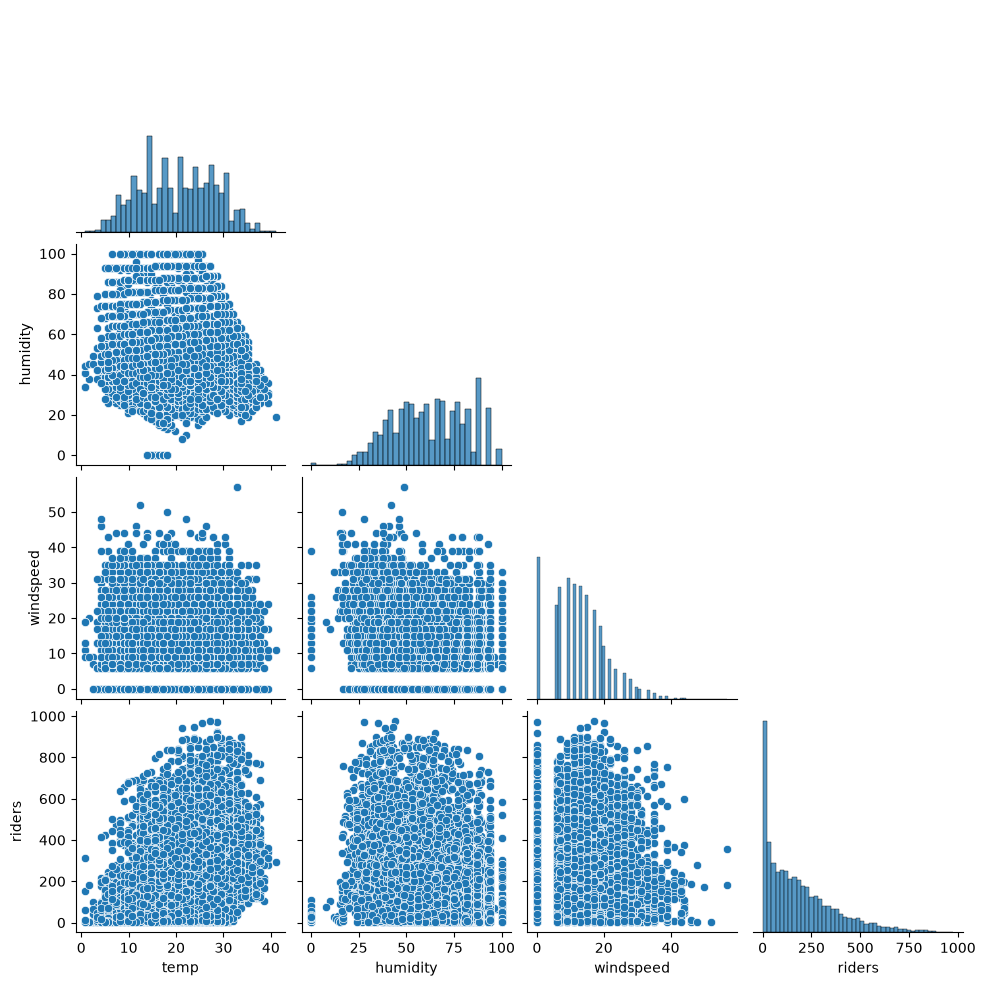

In [102]:
# corner=True, remove mirrored graphs 
sns.pairplot(data= bikes_corr, corner=True)
# we can observe that the relations are not LINEAR

In [103]:
# I:
# assumed
# although this is probably violated since this is time-series data

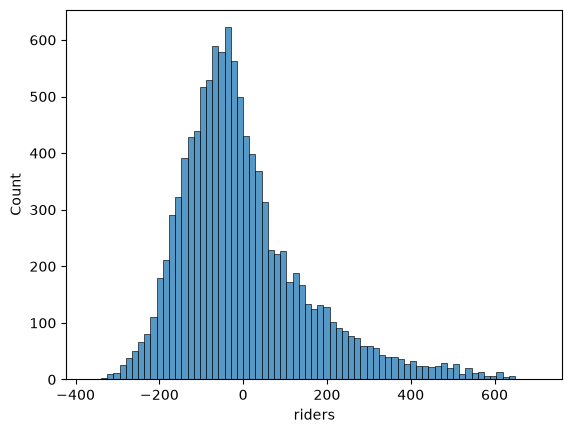

In [104]:
# N:
errors = y - y_predict
sns.histplot(errors)
error = round((y - y_predict)/y *100,2)

<Axes: ylabel='riders'>

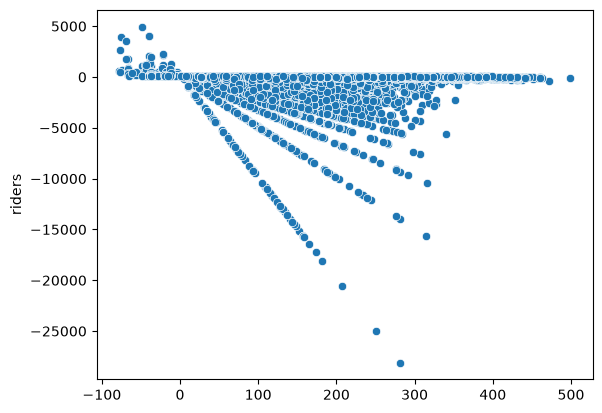

In [105]:
# E:
sns.scatterplot(x= y_predict, y= error)

In [106]:
# M/I:
# Honestly temperature might be a little correlated with season, but not enough to be worried


Yikes! We should probably not say anything very strong about the coefficients in our interpretation. 

# NOW YOU TRY

Let's make a better model.

Now your turn: Fit a model that uses _all_ x-variables (excluding `atemp`) as well as the **the hour of day**. One-hot encode columns accordingly, and check the assumptions.

In [107]:
# E


# Additional, not-really-BONUS topics

## ANRBT #1: Multicollinearity
Multicollinearity occurs when you have two or more $x$-variables that are correlated with each other. This phenomenon doesn't affect the quality of the model fit, but it completely destroys model inference (i.e., confidence intervals and hypothesis tests). In addition, it can also contribute to a **rank-deficient matrix**, meaning the model can't be fit at all!

## ANRBT #2: The Curse of Dimensionality
It turns out that the more variables we add to our model, the better it is. Actually, it doesn't even matter what this variable was, that will always be true. Even if it's completely irrelevant. That is, if we added the following variables to our model:

* Is there a sunspot on this day?
* The closing stock price of Apple that day.
* Whether or not Guy Fieri had pancakes for breakfast that day.
* A column of completely random standard normal variables

Our model is **guaranteed** to get better. But it isn't _really_ a better model, right? It turns out, we're modeling **noise**, not **signal**. We'll talk more about this phenomenon later.

## ANRBT #3: The `statsmodels` Library
`scikit-Learn` does not hold the monopoly in doing linear regression in Python. In fact, you may even like this better!

## ANRBT #4: Does the Scale of the Features Matter?

Let's say that temperature was measured in Fahrenheit, rather than Celsius. How would that affect the model?

In [108]:
# Create a new column for Fahrenheit temperature.


#### Rebuild the `LinearRegression` from above using the `temp_F` features instead.

In [109]:
# Create X and y.


# Instantiate and fit.


# Print the coefficients.


#### Convert 25 degrees Celsius to Fahrenheit.

#### Predict rentals for 77 degrees Fahrenheit.

#### Compare with the prediction for 25 degrees Celsius.

In [110]:
# Re-set up the model from earlier

# Examine the prediction


**Conclusion:** The scale of the features is irrelevant for linear regression models. When changing the scale, we simply change our interpretation of the coefficients and the intercept.

# Conclusions and Takeaways:
* Machine learning, aka statistical modeling, is an important and vast topic we'll spend much of our course exploring. It comes in many varieties for different situations.
* Linear regression is a **supervised "white-box" regression model**.
* As far as machine learning goes, OLS is very simple, yet still powerful.
* One of its more enticing feature is that its **coefficients are interpretable!**
* In the midst of all this, we learned how to handle dummy variables, something important for all of the models we'll learn about.